# Regridding

CESM writes the atmosphere on a spectral-element grid (`ncol`) and the ocean on a
curvilinear POP grid (`nlat`/`nlon`). `.x.regrid()` maps either onto a regular
lat/lon grid.

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import nc_time_axis  # registers the cftime axis converter for matplotlib
import x4c

x4c.set_style('journal')

# after set_style: it resets rcParams from matplotlibrc defaults, which includes the
# backend, so assert the inline backend last or figures are never captured
%matplotlib inline

# The tutorial runs against a reduced copy of a real CESM case. It is published as a
# GitHub Release asset rather than committed, so the first call downloads it into
# ~/.cache/x4c (override with $X4C_CACHE_DIR) and later calls reuse it. Set
# $X4C_SAMPLE_DIR to point at a copy you already have.
case_dir = x4c.fetch_sample_data(case='cesm1', verbose=False)
casename = os.path.basename(case_dir)
print('x4c', x4c.__version__)

x4c 2026.6.11


## Atmosphere: `ne16np4` to regular lat/lon

Weight files for the supported SE grids are looked up in the user cache, then next
to the package, and downloaded on demand if neither has them. Nothing about the call
changes.

In [2]:
fpath = os.path.join(
    case_dir, 'atm', 'proc', 'tseries', 'month_1',
    f'{casename}.cam.h0.TS.000101-000512.nc',
)
ds = x4c.open_dataset(fpath, comp='atm', grid='ne16np4', vn='TS', shift_time=True)

print('native  :', dict(ds.x.da.sizes))
ds_rgd = ds.x.regrid(dlon=2, dlat=2)
print('regridded:', dict(ds_rgd.x.da.sizes))

native  : {'time': 60, 'ncol': 13826}


regridded: {'time': 60, 'lat': 90, 'lon': 180}


## The area weight is re-derived, not carried over

This is the part worth understanding. The source weight (`area`, on `ncol`) does not
describe the output grid, so `regrid` replaces it with a weight for the target grid.
The consequence is that a global mean is consistent across the regrid, to within the
remapping error itself.

In [3]:
print('native gw dims    :', tuple(ds.attrs['gw'].dims))
print('regridded gw dims :', tuple(ds_rgd.attrs['gw'].dims))
print()

gm_native = float(ds.x.da.x.gm[0])
gm_rgd = float(ds_rgd.x.da.x.gm[0])
print(f'global mean, native grid    : {gm_native:.4f} K')
print(f'global mean, regridded      : {gm_rgd:.4f} K')
print(f'difference (remapping error): {gm_rgd - gm_native:+.4f} K')

native gw dims    : ('ncol',)
regridded gw dims : ('lat', 'lon')

global mean, native grid    : 294.8395 K
global mean, regridded      : 294.8384 K
difference (remapping error): -0.0011 K


Hemispheric means work after a regrid too, because the latitude metadata is
re-attached for the target grid.

In [4]:
print(f'NH mean after regrid: {float(ds_rgd.x.da.x.nhm[0]):.4f} K')
print(f'SH mean after regrid: {float(ds_rgd.x.da.x.shm[0]):.4f} K')

NH mean after regrid: 289.1330 K
SH mean after regrid: 300.5438 K


## Native versus regridded, side by side

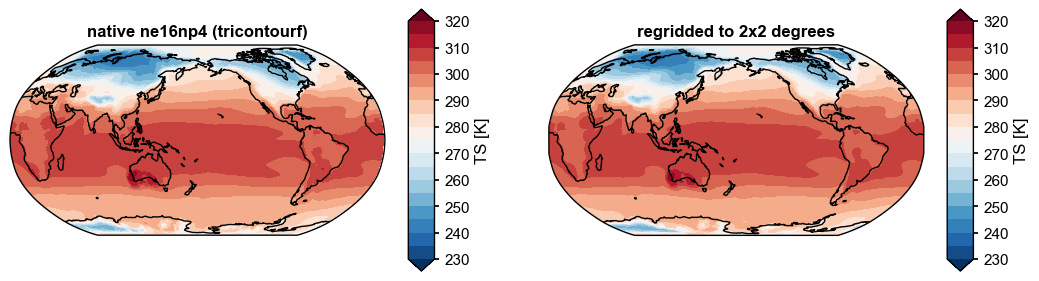

In [5]:
ax_loc = {'a': (0, 0), 'b': (0, 1)}
projs = {k: 'Robinson' for k in ax_loc}
projs_kws = {k: {'central_longitude': 180} for k in ax_loc}
fig, axd = x4c.subplots(1, 2, ax_loc=ax_loc, projs=projs, projs_kws=projs_kws,
                        figsize=(13, 3.4), wspace=0.15)

levels = np.linspace(230, 320, 19)
ds.x.da.isel(time=0).x.plot(ax=axd['a'], levels=levels,
                            title='native ne16np4 (tricontourf)')
ds_rgd.x.da.isel(time=0).x.plot(ax=axd['b'], levels=levels,
                                title='regridded to 2x2 degrees')
x4c.showfig(fig)

## Ocean: POP `g16` to regular lat/lon

The ocean grid is curvilinear, with 2-D `TLAT`/`TLONG` coordinate arrays. `regrid`
uses those directly; `gs` selects the T-grid (default) or the U-grid.

In [6]:
fpath_ocn = os.path.join(
    case_dir, 'ocn', 'proc', 'tseries', 'month_1',
    f'{casename}.pop.h.SSH.000101-000512.nc',
)
ds_ocn = x4c.open_dataset(fpath_ocn, comp='ocn', grid='g16', vn='SSH', shift_time=True)
print('native   :', dict(ds_ocn.x.da.sizes))
print('gw       :', tuple(ds_ocn.attrs['gw'].dims), '(POP cell areas, TAREA)')

ds_ocn_rgd = ds_ocn.x.regrid(dlon=2, dlat=2)
print('regridded:', dict(ds_ocn_rgd.x.da.sizes))

native   : {'time': 60, 'nlat': 384, 'nlon': 320}
gw       : ('nlat', 'nlon') (POP cell areas, TAREA)


regridded: {'time': 60, 'lat': 90, 'lon': 180}


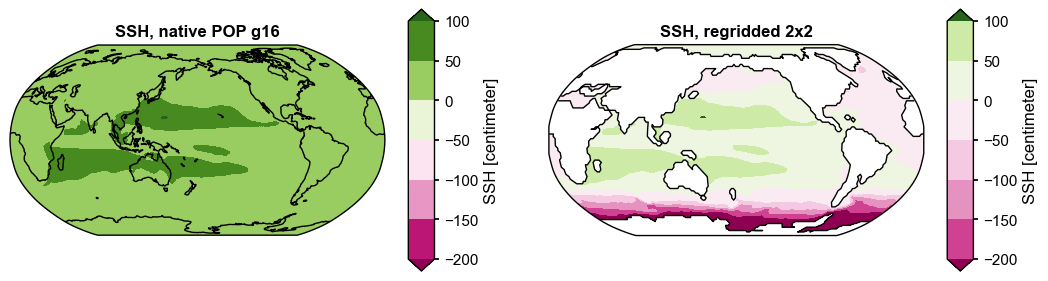

In [7]:
ax_loc = {'a': (0, 0), 'b': (0, 1)}
projs = {k: 'Robinson' for k in ax_loc}
projs_kws = {k: {'central_longitude': 180} for k in ax_loc}
fig, axd = x4c.subplots(1, 2, ax_loc=ax_loc, projs=projs, projs_kws=projs_kws,
                        figsize=(13, 3.4), wspace=0.15)

ds_ocn.x.da.isel(time=0).x.plot(ax=axd['a'], title='SSH, native POP g16')
ds_ocn_rgd.x.da.isel(time=0).x.plot(ax=axd['b'], title='SSH, regridded 2x2')
x4c.showfig(fig)

## Vertical interpolation to pressure levels

For a hybrid-sigma field, `.x.get_plev()` interpolates to pressure levels using the
surface pressure and the hybrid coefficients in the file. This needs `geocat-comp`,
which is an optional dependency.

The sample ships `T` for years 1-2 only (a 3-D atmosphere field is far larger than a
2-D one), so this cell selects that span.

In [8]:
fpath_T = os.path.join(
    case_dir, 'atm', 'proc', 'tseries', 'month_1',
    f'{casename}.cam.h0.T.000101-000112.nc',
)
fpath_PS = os.path.join(
    case_dir, 'atm', 'proc', 'tseries', 'month_1',
    f'{casename}.cam.h0.PS.000101-000512.nc',
)

ds_T = x4c.open_dataset(fpath_T, comp='atm', grid='ne16np4', vn='T', shift_time=True)
ds_PS = x4c.open_dataset(fpath_PS, comp='atm', grid='ne16np4', vn='PS', shift_time=True)

# `T` in the sample covers year 1 only while `PS` covers years 1-5, so line the two
# up before interpolating -- geocat needs them on the same time axis
ds_PS = ds_PS.sel(time=ds_T.time)
print('T  dims:', dict(ds_T.x.da.sizes))
print('PS dims:', dict(ds_PS.x.da.sizes))

T  dims: {'time': 12, 'lev': 30, 'ncol': 13826}
PS dims: {'time': 12, 'ncol': 13826}


after get_plev: {'time': 12, 'plev': 2, 'ncol': 13826}


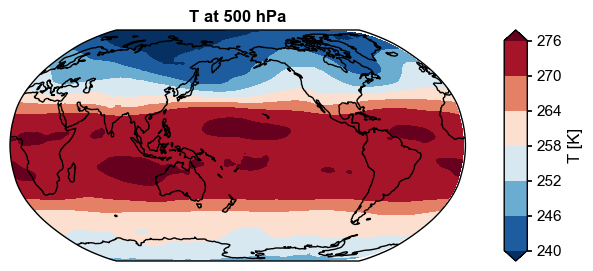

In [9]:
try:
    ds_plev = ds_T.x.get_plev(ps=ds_PS, new_levels=np.array([50000.0, 85000.0]))
    T_plev = ds_plev.x.da
    print('after get_plev:', dict(T_plev.sizes))
    fig, ax = T_plev.isel(time=0, plev=0).x.plot(title='T at 500 hPa')
    x4c.showfig(fig)
except ImportError as e:
    print('skipped:', e)